# Лабораторная работа №1: Основные технологии машинного обучения
1. Текстовое описание набора данных

В данной работе используется Wine recognition dataset (набор данных о винах).
Этот датасет является результатом химического анализа вин, произведенных из трех разных культиваров (сортов) винограда в одном и том же регионе Италии.
Основные характеристики:
В наборе данных представлено 13 измерений различных химических компонентов, содержащихся в винах:

1) Alcohol
2) Malic acid
3) Ash
4) Alcalinity of ash
5) Magnesium
6) Total phenols
7) Flavanoids
8) Nonflavanoid phenols
9) Proanthocyanins
10)Color intensity
11)Hue
12)OD280/OD315 of diluted wines
13)Proline

Целевая переменная: сорт винограда (классы 0, 1, 2).

# 2. Загрузка данных и основные характеристики

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Список названий колонок (согласно спецификации UCI Wine dataset)
column_names = [
    'Class', 'Alcohol', 'Malic_acid', 'Ash', 'Alcalinity_of_ash', 
    'Magnesium', 'Total_phenols', 'Flavanoids', 'Nonflavanoid_phenols', 
    'Proanthocyanins', 'Color_intensity', 'Hue', 'OD280_OD315', 'Proline'
]

# Загрузка данных из файла. 
# Если файл лежит в той же папке, что и ноутбук:
df = pd.read_csv('~/files/TMO/lab1/wine.data', header=None, names=column_names)

# Посмотрим на первые 5 строк
df.head()

,Class,Alcohol,Malic_acid,Ash,Alcalinity_of_ash,Magnesium,Total_phenols,Flavanoids,Nonflavanoid_phenols,Proanthocyanins,Color_intensity,Hue,OD280_OD315,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


Основные характеристики:

In [6]:
# Размерность
print(f"Формат данных: {df.shape}")

# Информация о типах и пропусках
print("\nОбщая информация:")
df.info()

# Проверка на наличие пустых значений
print(f"\nКоличество пропусков в данных: {df.isnull().sum().sum()}")

# Статистические показатели
print("\nСтатистическое описание:")
df.describe()

Формат данных: (178, 14)

Общая информация:
<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Class                 178 non-null    int64  
 1   Alcohol               178 non-null    float64
 2   Malic_acid            178 non-null    float64
 3   Ash                   178 non-null    float64
 4   Alcalinity_of_ash     178 non-null    float64
 5   Magnesium             178 non-null    int64  
 6   Total_phenols         178 non-null    float64
 7   Flavanoids            178 non-null    float64
 8   Nonflavanoid_phenols  178 non-null    float64
 9   Proanthocyanins       178 non-null    float64
 10  Color_intensity       178 non-null    float64
 11  Hue                   178 non-null    float64
 12  OD280_OD315           178 non-null    float64
 13  Proline               178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19

,Class,Alcohol,Malic_acid,Ash,Alcalinity_of_ash,Magnesium,Total_phenols,Flavanoids,Nonflavanoid_phenols,Proanthocyanins,Color_intensity,Hue,OD280_OD315,Proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,1.938202,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.775035,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,1.000000,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,1.000000,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,2.000000,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,3.000000,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,3.000000,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


3. Визуальное исследование датасета
3.1 Распределение целевой переменной

Посмотрим, насколько сбалансированы классы вин.

/tmp/ipykernel_17547/1631977944.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class', data=df, palette='Set2')


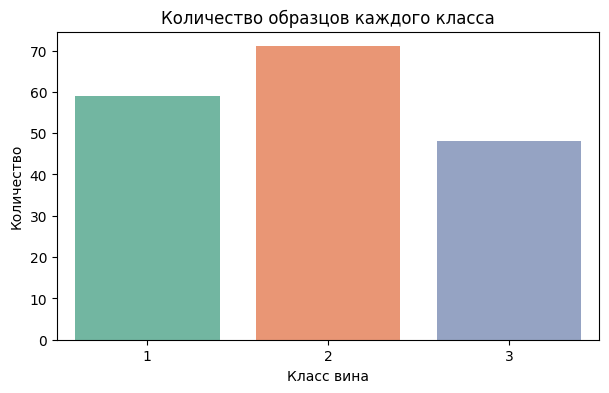

In [8]:
plt.figure(figsize=(7, 4))
sns.countplot(x='Class', data=df, palette='Set2')
plt.title('Количество образцов каждого класса')
plt.xlabel('Класс вина')
plt.ylabel('Количество')
plt.show()

3.2 Распределение ключевых признаков

Построим гистограммы для понимания распределения числовых данных.

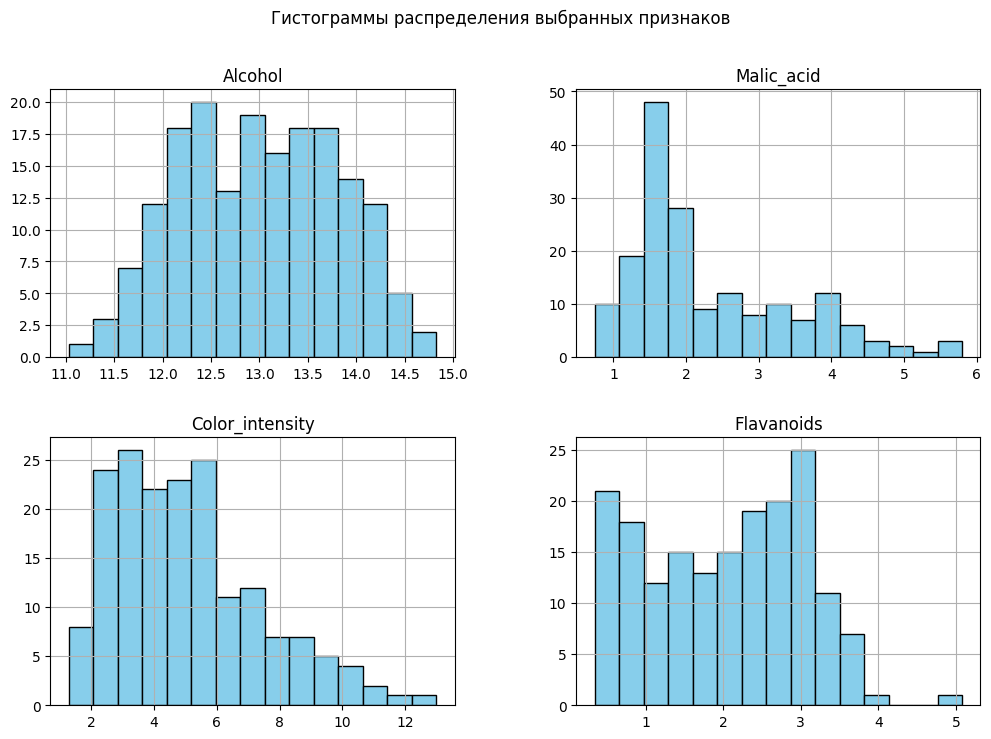

In [10]:
# Выберем несколько интересных признаков
selected_features = ['Alcohol', 'Malic_acid', 'Color_intensity', 'Flavanoids']

df[selected_features].hist(figsize=(12, 8), bins=15, color='skyblue', edgecolor='black')
plt.suptitle('Гистограммы распределения выбранных признаков')
plt.show()

3.3 Диаграммы размаха (Boxplots)

Позволяют увидеть различия в характеристиках между классами и наличие выбросов.

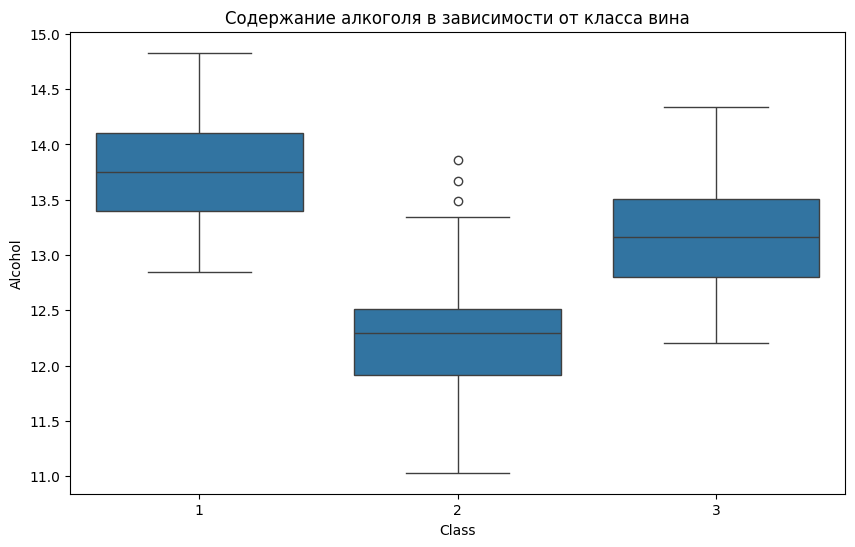

In [11]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Class', y='Alcohol', data=df)
plt.title('Содержание алкоголя в зависимости от класса вина')
plt.show()

3.4 Парные диаграммы (Pairplot)

Парные диаграммы позволяют одновременно увидеть распределение каждого признака и его взаимосвязь с другими признаками, сгруппированными по классам вина. Мы выберем наиболее коррелирующие с целевой переменной признаки: Alcohol, Flavanoids, Color_intensity и Total_phenols.

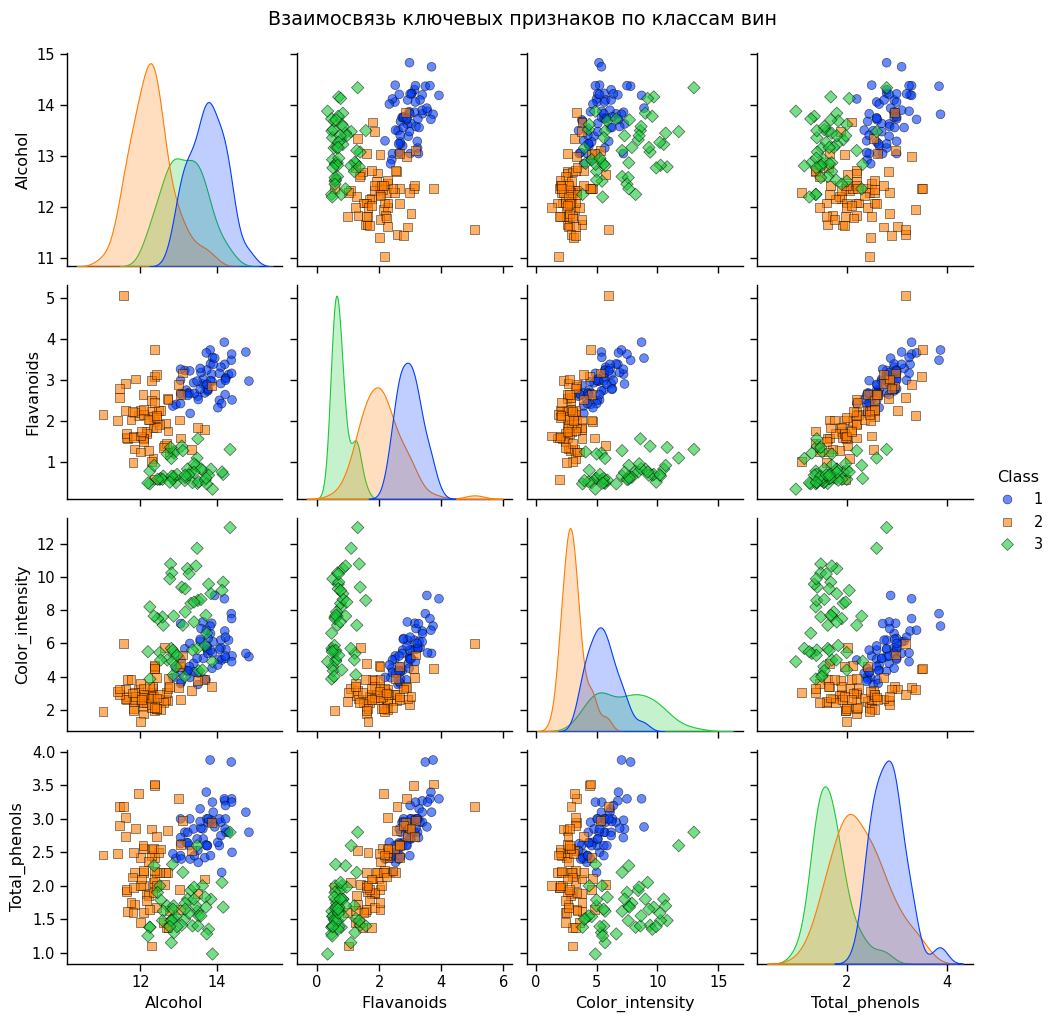

In [16]:
# Выбираем подмножество наиболее информативных признаков и целевую переменную
selected_columns = ['Class', 'Alcohol', 'Flavanoids', 'Color_intensity', 'Total_phenols']

# Построение Pairplot
# hue='Class' окрашивает точки в зависимости от сорта вина
# palette='bright' задает контрастные цвета для классов
# corner=True позволяет скрыть дублирующиеся графики выше диагонали
sns.set_context("paper", font_scale=1.2)
pair_plot = sns.pairplot(df[selected_columns], 
                         hue='Class', 
                         palette='bright', 
                         diag_kind='kde', 
                         markers=["o", "s", "D"],
                         plot_kws={'alpha': 0.6, 's': 40, 'edgecolor': 'k'})

pair_plot.fig.suptitle('Взаимосвязь ключевых признаков по классам вин', y=1.02)
plt.show()

4. Информация о корреляции признаков

Анализ корреляции позволяет выявить зависимости между признаками и понять, какие из них сильнее всего влияют на целевую переменную.

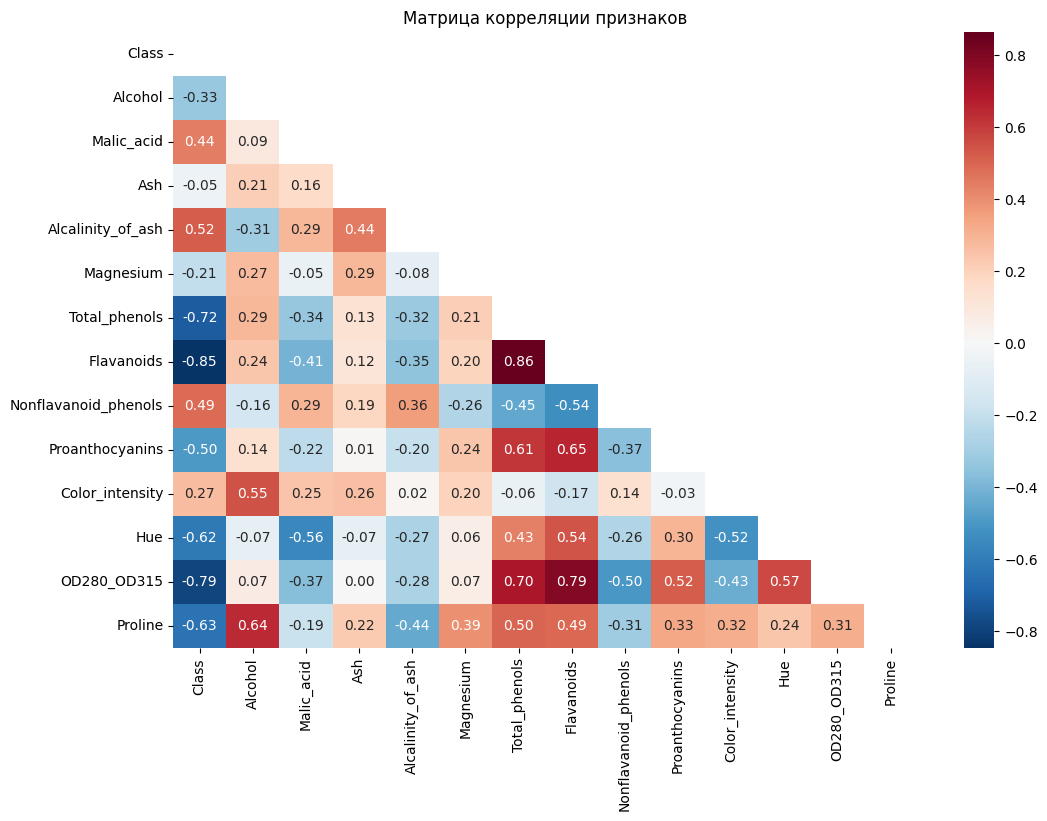

In [14]:
# Рассчитываем корреляцию
# Метод Пирсона по умолчанию
corr_matrix = df.corr()

# Визуализация с помощью тепловой карты
plt.figure(figsize=(12, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool)) # Маска для скрытия дублирующейся верхней части
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='RdBu_r', center=0)
plt.title('Матрица корреляции признаков')
plt.show()

Выводы по корреляции:

Мы видим сильную положительную корреляцию между total_phenols и flavanoids (около 0.86).

Признак flavanoids имеет высокую отрицательную корреляцию с target (целевой переменной), что делает его важным для классификации.

Большинство признаков имеют значимые зависимости, что подтверждает пригодность данных для обучения моделей.